# Character-Level Text Generation using Vanilla RNN

Given a short story corpus, build a character-level Vanilla RNN from scratch that can learn the writing style and generate new text passages when provided with a starting phrase.

---

## Dataset

| Property | Details |
|---|---|
| File | `clockmaker_corpus.txt` |
| Content | A short story passage (~800 characters) |
| Format | Plain text |

---

## Tasks

- **Load and Preprocess**: Read the text file, convert to lowercase, build character-to-index and index-to-character mappings, convert full text to a list of integer indices
- **Build Vanilla RNN**: Create 5 weight matrices with gradient tracking enabled, use one-hot encoding for input, implement forward pass manually over time steps
- **Train the Model**: Sample random input-target batches (target shifted by 1 character), compute loss using `nn.CrossEntropyLoss`, update weights with manual SGD, apply gradient clipping
- **Compute Perplexity**: Evaluate the trained model by computing `exp(average cross-entropy loss)` over non-overlapping chunks of the corpus
- **Generate Text**: Implement a `predict` function that generates new characters using temperature-scaled softmax and `torch.multinomial` sampling

---

## Expected Variables

| Variable | Type | Description |
|---|---|---|
| `params` | `list` | Trained parameters `[W_xh, W_hh, b_h, W_hq, b_q]` with `requires_grad=True` |
| `training_losses` | `list` | One loss value per epoch (length = 1000) |
| `perplexity_score` | `float` | `exp(avg cross-entropy loss)` on the corpus |

## Expected Function

| Function | Signature | Returns |
|---|---|---|
| `predict` | `predict(prefix, num_chars, params, hidden_size, temperature)` | Generated text as `str` |

In [1]:
# Run this cell before writing your solution
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math
import urllib.request

url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/clockmaker_corpus.txt"
text = urllib.request.urlopen(url).read().decode('utf-8').lower()


Corpus length: 805
Vocabulary size: 27
Characters: ['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y']

Parameter shapes:
(27, 128)
(128, 128)
(128,)
(128, 27)
(27,)
Epoch  100/1000 Loss: 2.5818
Epoch  200/1000 Loss: 2.1601
Epoch  300/1000 Loss: 1.8779
Epoch  400/1000 Loss: 1.4917
Epoch  500/1000 Loss: 1.3230
Epoch  600/1000 Loss: 1.0264
Epoch  700/1000 Loss: 0.8423
Epoch  800/1000 Loss: 0.6153
Epoch  900/1000 Loss: 0.4250
Epoch 1000/1000 Loss: 0.4894

Training completed.
Number of recorded losses: 1000
Initial loss: 3.2955455780029297
Final loss: 0.4893541634082794


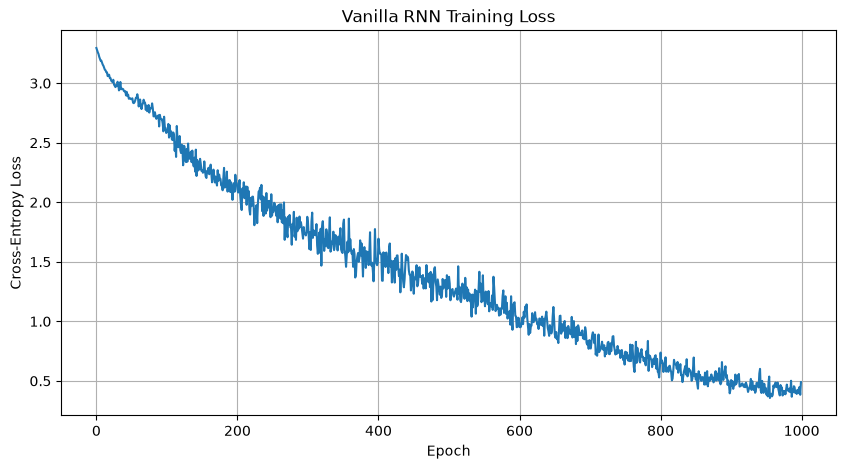


Perplexity: 1.5680627358274064

Generated Text:
the window and watch the borde the sun rose above the hills.
the clockmaker wan oree..
the little cat for finding the clock in the cold winter the snow was the missing cat cbm fitte clock.
he searched the

FINAL EVALUATION
params type: <class 'list'>
Number of parameters: 5

Parameter shapes:
W_xh: torch.Size([27, 128])
W_hh: torch.Size([128, 128])
b_h : torch.Size([128])
W_hq: torch.Size([128, 27])
b_q : torch.Size([27])

Training losses: 1000
Initial loss: 3.2955455780029297
Final loss: 0.4893541634082794

Perplexity: 1.5680627358274064

Generated text length: 204
Starts with 'the ': True
Only corpus characters: True


In [2]:
# ============================================================
# Character-Level Text Generation using Vanilla RNN
# ============================================================

# ------------------------------------------------------------
# 1. Load and Preprocess
# ------------------------------------------------------------

# text is already loaded in the previous cell and converted
# to lowercase.

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

data = [char_to_idx[ch] for ch in text]

print("Corpus length:", len(text))
print("Vocabulary size:", vocab_size)
print("Characters:", chars)


# ------------------------------------------------------------
# 2. Hyperparameters
# ------------------------------------------------------------

hidden_size = 128
batch_size = 16
seq_len = 25
learning_rate = 0.5
epochs = 1000
clip_theta = 1.0

torch.manual_seed(42)


# ------------------------------------------------------------
# 3. Initialize the 5 RNN Parameters
# ------------------------------------------------------------

W_xh = (torch.randn(vocab_size, hidden_size) * 0.01).requires_grad_(True)
W_hh = (torch.randn(hidden_size, hidden_size) * 0.01).requires_grad_(True)
b_h = torch.zeros(hidden_size, requires_grad=True)

W_hq = (torch.randn(hidden_size, vocab_size) * 0.01).requires_grad_(True)
b_q = torch.zeros(vocab_size, requires_grad=True)

params = [W_xh, W_hh, b_h, W_hq, b_q]

print("\nParameter shapes:")
for p in params:
    print(tuple(p.shape))


# ------------------------------------------------------------
# 4. Vanilla RNN Forward Pass
# ------------------------------------------------------------

def rnn_forward(X, params, hidden_size):
    """
    X shape:
        (batch_size, seq_len)

    Returns:
        logits: (batch_size, seq_len, vocab_size)
        hidden_state: final hidden state
    """

    W_xh, W_hh, b_h, W_hq, b_q = params

    batch_size_current = X.shape[0]

    # Initial hidden state
    h = torch.zeros(
        batch_size_current,
        hidden_size,
        dtype=torch.float32
    )

    outputs = []

    # Process one character at a time
    for t in range(X.shape[1]):

        # One-hot encode current character
        x_t = F.one_hot(
            X[:, t],
            num_classes=vocab_size
        ).float()

        # Hidden state:
        # h_t = tanh(x_t W_xh + h_(t-1) W_hh + b_h)
        h = torch.tanh(
            x_t @ W_xh +
            h @ W_hh +
            b_h
        )

        # Output:
        # q_t = h_t W_hq + b_q
        q = h @ W_hq + b_q

        outputs.append(q)

    # (seq_len, batch_size, vocab_size)
    outputs = torch.stack(outputs, dim=1)

    return outputs, h


# ------------------------------------------------------------
# 5. Helper Function to Create Random Batches
# ------------------------------------------------------------

def get_batch(data, batch_size, seq_len):
    """
    Creates random input-target batches.

    X contains characters at positions:
        t

    Y contains the next characters:
        t + 1
    """

    max_start = len(data) - seq_len - 1

    starts = torch.randint(
        0,
        max_start + 1,
        (batch_size,)
    )

    X = torch.stack([
        torch.tensor(
            data[start:start + seq_len],
            dtype=torch.long
        )
        for start in starts.tolist()
    ])

    Y = torch.stack([
        torch.tensor(
            data[start + 1:start + seq_len + 1],
            dtype=torch.long
        )
        for start in starts.tolist()
    ])

    return X, Y


# ------------------------------------------------------------
# 6. Loss Function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# 7. Train the Vanilla RNN
# ------------------------------------------------------------

training_losses = []

for epoch in range(epochs):

    # --------------------------------------------------------
    # Random batch
    # --------------------------------------------------------
    X_batch, Y_batch = get_batch(
        data,
        batch_size,
        seq_len
    )

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------
    logits, _ = rnn_forward(
        X_batch,
        params,
        hidden_size
    )

    # --------------------------------------------------------
    # Reshape for CrossEntropyLoss
    #
    # logits:
    #   (batch, seq, vocab)
    #
    # targets:
    #   (batch, seq)
    # --------------------------------------------------------
    loss = criterion(
        logits.reshape(-1, vocab_size),
        Y_batch.reshape(-1)
    )

    # --------------------------------------------------------
    # Clear old gradients
    # --------------------------------------------------------
    for p in params:
        if p.grad is not None:
            p.grad.zero_()

    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------
    loss.backward()

    # --------------------------------------------------------
    # Gradient clipping
    # --------------------------------------------------------
    torch.nn.utils.clip_grad_norm_(
        params,
        max_norm=clip_theta
    )

    # --------------------------------------------------------
    # Manual SGD update
    # --------------------------------------------------------
    with torch.no_grad():

        for p in params:
            p -= learning_rate * p.grad

    # --------------------------------------------------------
    # Store one loss value per epoch
    # --------------------------------------------------------
    training_losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1:4d}/{epochs} "
            f"Loss: {loss.item():.4f}"
        )


# ------------------------------------------------------------
# 8. Verify Training Loss
# ------------------------------------------------------------

print("\nTraining completed.")
print("Number of recorded losses:", len(training_losses))
print("Initial loss:", training_losses[0])
print("Final loss:", training_losses[-1])


# ------------------------------------------------------------
# 9. Plot Training Loss
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(training_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Vanilla RNN Training Loss")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 10. Compute Perplexity
# ------------------------------------------------------------

def calculate_perplexity(data, params, hidden_size, seq_len):
    """
    Computes perplexity using non-overlapping chunks
    of the corpus.

    Perplexity = exp(average cross-entropy loss)
    """

    W_xh, W_hh, b_h, W_hq, b_q = params

    total_loss = 0.0
    total_characters = 0

    # Use non-overlapping chunks
    # Need seq_len + 1 characters to predict seq_len targets.
    for start in range(
        0,
        len(data) - seq_len,
        seq_len
    ):

        chunk = data[start:start + seq_len + 1]

        if len(chunk) < seq_len + 1:
            continue

        X = torch.tensor(
            chunk[:-1],
            dtype=torch.long
        ).unsqueeze(0)

        Y = torch.tensor(
            chunk[1:],
            dtype=torch.long
        ).unsqueeze(0)

        with torch.no_grad():

            logits, _ = rnn_forward(
                X,
                params,
                hidden_size
            )

            loss = criterion(
                logits.reshape(-1, vocab_size),
                Y.reshape(-1)
            )

        total_loss += loss.item() * Y.numel()
        total_characters += Y.numel()

    average_loss = total_loss / total_characters

    perplexity = math.exp(average_loss)

    return perplexity


perplexity_score = calculate_perplexity(
    data,
    params,
    hidden_size,
    seq_len
)

print("\nPerplexity:", perplexity_score)


# ------------------------------------------------------------
# 11. Text Generation / Prediction
# ------------------------------------------------------------

def predict(
    prefix,
    num_chars,
    params,
    hidden_size,
    temperature
):
    """
    Generate text character-by-character.

    Uses temperature-scaled softmax and
    torch.multinomial sampling.
    """

    W_xh, W_hh, b_h, W_hq, b_q = params

    # Convert prefix to lowercase
    prefix = prefix.lower()

    # Make sure every prefix character exists
    for ch in prefix:
        if ch not in char_to_idx:
            raise ValueError(
                f"Character {repr(ch)} is not present in the corpus."
            )

    # Initial hidden state
    h = torch.zeros(
        1,
        hidden_size,
        dtype=torch.float32
    )

    generated = prefix

    with torch.no_grad():

        # ----------------------------------------------------
        # Feed the prefix through the RNN
        # ----------------------------------------------------
        for ch in prefix:

            x = torch.tensor(
                [char_to_idx[ch]],
                dtype=torch.long
            )

            x_one_hot = F.one_hot(
                x,
                num_classes=vocab_size
            ).float()

            h = torch.tanh(
                x_one_hot @ W_xh +
                h @ W_hh +
                b_h
            )

        # ----------------------------------------------------
        # Generate new characters
        # ----------------------------------------------------
        for _ in range(num_chars):

            logits = h @ W_hq + b_q

            # Temperature scaling
            scaled_logits = logits / temperature

            probabilities = F.softmax(
                scaled_logits,
                dim=-1
            )

            # Sample instead of argmax
            next_idx = torch.multinomial(
                probabilities,
                num_samples=1
            )

            next_idx = next_idx.item()

            next_char = idx_to_char[next_idx]

            generated += next_char

            # Feed generated character back into RNN
            x = torch.tensor(
                [next_idx],
                dtype=torch.long
            )

            x_one_hot = F.one_hot(
                x,
                num_classes=vocab_size
            ).float()

            h = torch.tanh(
                x_one_hot @ W_xh +
                h @ W_hh +
                b_h
            )

    return generated


# ------------------------------------------------------------
# 12. Generate Text
# ------------------------------------------------------------

generated_text = predict(
    "the ",
    200,
    params,
    hidden_size,
    0.8
)

print("\nGenerated Text:")
print(generated_text)


# ------------------------------------------------------------
# 13. Final Evaluation Checks
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL EVALUATION")
print("=" * 60)

print("params type:", type(params))
print("Number of parameters:", len(params))

print("\nParameter shapes:")
print("W_xh:", params[0].shape)
print("W_hh:", params[1].shape)
print("b_h :", params[2].shape)
print("W_hq:", params[3].shape)
print("b_q :", params[4].shape)

print("\nTraining losses:", len(training_losses))
print("Initial loss:", training_losses[0])
print("Final loss:", training_losses[-1])

print("\nPerplexity:", perplexity_score)

print("\nGenerated text length:", len(generated_text))
print("Starts with 'the ':", generated_text.startswith("the "))

valid_chars = all(
    ch in char_to_idx
    for ch in generated_text
)

print("Only corpus characters:", valid_chars)

print("=" * 60)

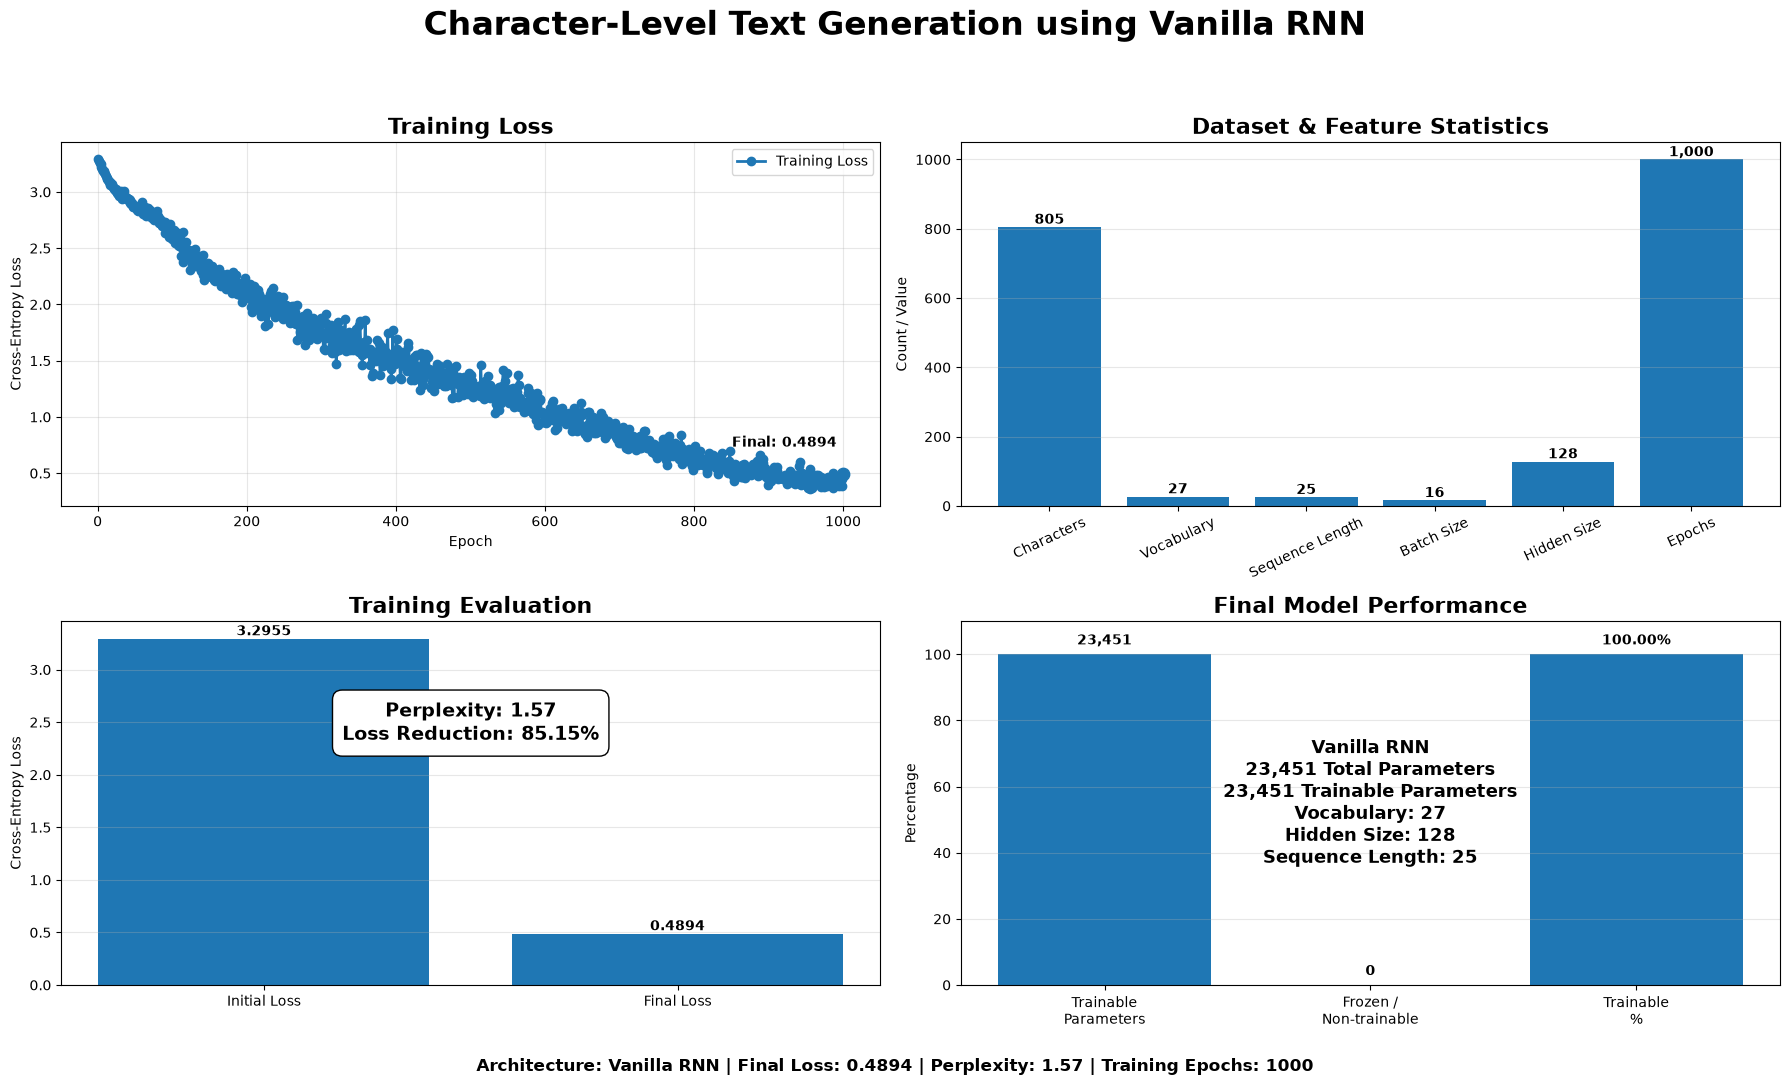

VISUALIZATION SAVED
Vanilla_RNN_Visualization.png


In [3]:
# ============================================================
# FINAL VISUALIZATION DASHBOARD
# Vanilla RNN - Character-Level Text Generation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------------
# Helper: parameter statistics
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in params
)

trainable_params = sum(
    p.numel()
    for p in params
    if p.requires_grad
)

non_trainable_params = total_params - trainable_params

trainable_percentage = (
    trainable_params / total_params * 100
    if total_params > 0 else 0
)

# ------------------------------------------------------------
# Training statistics
# ------------------------------------------------------------

initial_loss = training_losses[0]
final_loss = training_losses[-1]

loss_reduction = (
    (initial_loss - final_loss)
    / initial_loss
    * 100
)

# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------

text_length = len(text)
vocabulary_size = len(chars)

# ------------------------------------------------------------
# Create dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11)
)

fig.suptitle(
    "Character-Level Text Generation using Vanilla RNN",
    fontsize=24,
    fontweight="bold"
)

# ============================================================
# TOP LEFT
# Training Loss
# ============================================================

ax = axes[0, 0]

epochs_axis = np.arange(
    1,
    len(training_losses) + 1
)

ax.plot(
    epochs_axis,
    training_losses,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

ax.set_title(
    "Training Loss",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

# Mark final loss

ax.scatter(
    len(training_losses),
    final_loss,
    s=80,
    zorder=5
)

ax.annotate(
    f"Final: {final_loss:.4f}",
    (
        len(training_losses),
        final_loss
    ),
    xytext=(-80, 20),
    textcoords="offset points",
    fontweight="bold"
)

# ============================================================
# TOP RIGHT
# Dataset & Feature Statistics
# ============================================================

ax = axes[0, 1]

stats_names = [
    "Characters",
    "Vocabulary",
    "Sequence Length",
    "Batch Size",
    "Hidden Size",
    "Epochs"
]

stats_values = [
    text_length,
    vocabulary_size,
    seq_len,
    batch_size,
    hidden_size,
    epochs
]

bars = ax.bar(
    stats_names,
    stats_values
)

ax.set_title(
    "Dataset & Feature Statistics",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Count / Value")

ax.tick_params(
    axis="x",
    rotation=25
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    stats_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# ============================================================
# BOTTOM LEFT
# Training Evaluation
# ============================================================

ax = axes[1, 0]

metric_names = [
    "Initial Loss",
    "Final Loss"
]

metric_values = [
    initial_loss,
    final_loss
]

bars = ax.bar(
    metric_names,
    metric_values
)

ax.set_title(
    "Training Evaluation",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Cross-Entropy Loss")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    metric_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.72,
    f"Perplexity: {perplexity_score:.2f}\n"
    f"Loss Reduction: {loss_reduction:.2f}%",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# BOTTOM RIGHT
# Final Model Performance
# ============================================================

ax = axes[1, 1]

performance_names = [
    "Trainable\nParameters",
    "Frozen /\nNon-trainable",
    "Trainable\n%"
]

performance_values = [
    trainable_params,
    non_trainable_params,
    trainable_percentage
]

# Normalize first two for display while keeping
# actual parameter values in annotations.

display_values = [
    100 if total_params > 0 else 0,
    0 if total_params > 0 else 0,
    trainable_percentage
]

bars = ax.bar(
    performance_names,
    display_values
)

ax.set_ylim(
    0,
    110
)

ax.set_ylabel("Percentage")

ax.set_title(
    "Final Model Performance",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for i, bar in enumerate(bars):

    if i == 0:
        label = f"{trainable_params:,}"
    elif i == 1:
        label = f"{non_trainable_params:,}"
    else:
        label = f"{trainable_percentage:.2f}%"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label,
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.50,
    "Vanilla RNN\n"
    f"{total_params:,} Total Parameters\n"
    f"{trainable_params:,} Trainable Parameters\n"
    f"Vocabulary: {vocabulary_size}\n"
    f"Hidden Size: {hidden_size}\n"
    f"Sequence Length: {seq_len}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.5,
    0.015,
    f"Architecture: Vanilla RNN | "
    f"Final Loss: {final_loss:.4f} | "
    f"Perplexity: {perplexity_score:.2f} | "
    f"Training Epochs: {len(training_losses)}",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.94]
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output_file = "Vanilla_RNN_Visualization.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("VISUALIZATION SAVED")
print("=" * 70)
print(output_file)